# Signalling synapses using the volume transmitter

The volume transmitter can be used to send discrete signals to synapses, such as "update your weight with a random increment" or "undo the last change and go back to the previous weight". This uses the "multiplicity" event attribute in NEST Simulator.

In [1]:
%matplotlib inline

from typing import List, Optional

import matplotlib as mpl

mpl.rcParams["axes.formatter.useoffset"] = False
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "k"
mpl.rcParams["grid.linestyle"] = ":"
mpl.rcParams["grid.linewidth"] = 0.5
mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["figure.figsize"] = [8., 3.]

import matplotlib.pyplot as plt
import nest
import numpy as np
import os
import random
import re
import time

from pynestml.codegeneration.nest_code_generator_utils import NESTCodeGeneratorUtils
from pynestml.codegeneration.nest_tools import NESTTools


             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0-post0.dev14
 Built  : May  7 2026 23:17:50

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



## Generating code with NESTML

To generate fast code, NESTML needs to process the synapse model together with the neuron model that will be its postsynaptic partner in the network instantiantion (see https://nestml.readthedocs.io/en/latest/nestml_language/synapses_in_nestml.html#generating-code).

In this tutorial, we will use a very simple integrate-and-fire model, where arriving spikes cause an instantaneous increment of the membrane potential, the "iaf_psc_delta" model.

When NESTML is invoked, the C++ code is generated for the models, and then built (compiled) as a NEST extension module, which is then loaded into the NEST kernel at runtime using ``nest.Install()``.

The resulting neuron and synapse model names are returned by the function, because when generating code for plastic synapses, there is typically a tight integration of the generated with code with that of the postsynaptic neuron model. For more information about this, please see the NESTML documentation section [Generating code for plastic synapses](https://nestml.readthedocs.io/en/latest/running/running_nest.html#generating-code-for-plastic-synapses). Hence, the resulting model names are composed of associated neuron and synapse partners, because of the co-generation, for example, ``"jump_and_reset_synapse__with_iaf_psc_delta"`` and ``"iaf_psc_delta__with_jump_and_reset_synapse"``.

### Formulating the model in NESTML

We now go on to define the full synapse model in NESTML:

In [2]:
nestml_stdp_dopa_model = """
model jump_and_reset_synapse:

    state:
        w real = 1.
        w_prev real = 1.

    input:
        pre_spikes <- spike
        mod_spikes <- spike

    output:
        spike

    onReceive(mod_spikes):
        println("mod_spikes multiplicity = {mod_spikes}")
        if mod_spikes == 1:
            # this is the signal for: add a random increment to the weight
            w_prev = w
            w += random_normal(0, 1)
        else:
            # this is the signal for: go back to the previous weight
            w = w_prev

    onReceive(pre_spikes):
        # deliver spike to postsynaptic partner
        emit_spike(w)
"""

Generate the code, build the user module and make the model available to instantiate in NEST:

In [3]:
# generate and build code
module_name, neuron_model_name, synapse_model_name = \
    NESTCodeGeneratorUtils.generate_code_for("../../../models/neurons/iaf_psc_delta_neuron.nestml",
                                             nestml_stdp_dopa_model,
                                             mod_ports=["mod_spikes"],
                                             logging_level="WARNING",
                                             codegen_opts={"weight_variable": {"jump_and_reset_synapse": "w"}})


             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0-post0.dev14
 Built  : May  7 2026 23:17:50

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

[14,jump_and_reset_synapse_nestml, WARNING, [17:11;17:25]]: Operands of logical comparison operator not compatible.


## Running the simulation in NEST

Let's define a function that will instantiate a simple network with one presynaptic cell and one postsynaptic cell connected by a single synapse, then run a simulation and plot the results.



In [4]:
def run_network(pre_spike_times,
                vt_spike_times,
                neuron_model_name,
                synapse_model_name,
                resolution=.1, # [ms]
                delay=1., # [ms]
                sim_time=None,  # if None, computed from pre and post spike times
                synapse_parameters=None,  # optional dictionary passed to the synapse
                fname_snip="",
                debug=False):

    nest.ResetKernel()
    system_seed = int(time.time())
    nest.rng_seed = system_seed
    NESTTools.set_nest_verbosity("ERROR")
    nest.print_time = False
    nest.Install(module_name)
    nest.resolution = resolution

    # create spike_generators with these times
    pre_sg = nest.Create("spike_generator",
                         params={"spike_times": pre_spike_times})
    vt_sg = nest.Create("spike_generator",
                        params={"spike_times": vt_spike_times})

    # create  volume transmitter
    vt = nest.Create("volume_transmitter")
    vt_parrot = nest.Create("parrot_neuron")
    nest.Connect(vt_sg, vt_parrot)
    nest.Connect(vt_parrot, vt, syn_spec={"synapse_model": "static_synapse",
                                          "weight": 1.,
                                          "delay": 1.})   # delay is ignored!

    # set up custom synapse models
    wr = nest.Create("weight_recorder")
    nest.CopyModel(synapse_model_name, "stdp_nestml_rec",
                   {"weight_recorder": wr[0],
                    "w": 1.,
                    "delay": delay,
                    "receptor_type": 0,
                    "volume_transmitter": vt})

    # create parrot neurons and connect spike_generators
    pre_neuron = nest.Create("parrot_neuron")
    post_neuron = nest.Create(neuron_model_name)
    
    spikedet_pre = nest.Create("spike_recorder")
    spikedet_vt = nest.Create("spike_recorder")

    nest.Connect(pre_sg, pre_neuron, "one_to_one", syn_spec={"delay": 1.})
    nest.Connect(pre_neuron, post_neuron, "all_to_all", syn_spec={"synapse_model": "stdp_nestml_rec"})

    nest.Connect(pre_neuron, spikedet_pre)
    nest.Connect(vt_parrot, spikedet_vt)
    
    # get STDP synapse and weight before protocol
    syn = nest.GetConnections(source=pre_neuron, synapse_model="stdp_nestml_rec")
    if synapse_parameters is None:
        synapse_parameters = {}
    nest.SetStatus(syn, synapse_parameters)

    sim_time = np.amax(pre_spike_times) + 1.
    times = []
    weights = []
    while nest.biological_time < sim_time:
        nest.Simulate(nest.resolution)
        times.append(nest.biological_time)
        weights.append(syn.w)

    pre_spike_times_ = nest.GetStatus(spikedet_pre, "events")[0]["times"]
    vt_spike_times_ = nest.GetStatus(spikedet_vt, "events")[0]["times"]

    return times, weights#wr.events["times"], wr.events["weights"]

/home/charl/julich/nest-simulator-install/lib/python3.11/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
SetStatus() is deprecated and will be removed in a future version of NEST. Instead of SetStatus(nrns|conns, args), use nrns|conns.set(args).


mod_spikes multiplicity = 1 1 / s
mod_spikes multiplicity = 2 1 / s
mod_spikes multiplicity = 1 1 / s
mod_spikes multiplicity = 2 1 / s
mod_spikes multiplicity = 1 1 / s
mod_spikes multiplicity = 2 1 / s
mod_spikes multiplicity = 1 1 / s
mod_spikes multiplicity = 2 1 / s
mod_spikes multiplicity = 1 1 / s


/home/charl/julich/nest-simulator-install/lib/python3.11/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
GetStatus() is deprecated and will be removed in a future version of NEST. Instead of GetStatus(nrns|conns, args), use nrns|conns.get(args).


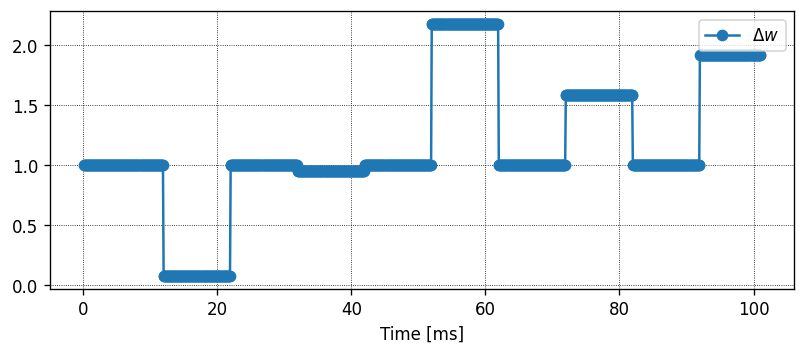

In [5]:
pre_spike_times = [100.] #np.linspace(10, 100, 10)
vt_spike_times = [10., 20., 20., 30., 40., 40., 50., 60., 60., 70., 80, 80., 90.]

timevec, dw = run_network(pre_spike_times,
                vt_spike_times,
                neuron_model_name,
                synapse_model_name)

fig, ax = plt.subplots()
ax.plot(timevec, dw, marker="o", label="$\\Delta w$")
ax.set_xlabel("Time [ms]")
ax.legend()
plt.show()
plt.close(fig)

Acknowledgements
----------------

This software was developed in part or in whole in the Human Brain Project, funded from the European Union’s Horizon 2020 Framework Programme for Research and Innovation under Specific Grant Agreements No. 720270, No. 785907 and No. 945539 (Human Brain Project SGA1, SGA2 and SGA3).

The authors would like to thank Moritz Helias for suggestions and support.


License
-------

This notebook (and associated files) is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 2 of the License, or (at your option) any later version.

This notebook (and associated files) is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU General Public License for more details.